# Homework 1

Author: Khanh Do

In [81]:
# imports
import math
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sklearn
from pathlib import Path

## Question 1

### Part A

In [116]:
def get_weighted_avg(x, theta):
    numerator = 0
    denominator = 0
    
    for x_i in x:
        w_i = math.exp(theta * x_i)
        numerator += w_i * x_i
        denominator += w_i
    
    return numerator / denominator

## Part B

In [117]:
x = [1,2,3,4]
thetas = [0, 0.1, 1, 2, 5, 10]

for theta in thetas:
    w = get_weighted_avg(x, theta)
    print(f"theta = {theta} -> weighted average = {w}")

theta = 0 -> weighted average = 2.5
theta = 0.1 -> weighted average = 2.6246471821038955
theta = 1 -> weighted average = 3.49265273458577
theta = 2 -> weighted average = 3.8448246580536996
theta = 5 -> weighted average = 3.99321635333831
theta = 10 -> weighted average = 3.9999545980089906


**Comment:** Using this example, we can see that as theta increases, the weighted average approaches the maximum value of `x`, which is $4$, but does not exceed it. Thus, we can see that as theta becomes large the weighted average calculation is dominated by the maximum value in the data.

### Part C

In [118]:
x = [1,2,3,4,5,6]
max_x = max(x)
low = max_x - 0.001

w = 0
theta = 6
while (w < low):
    w = get_weighted_avg(x, theta)
    if w < low:
        theta += 1

print(f"we found the weighted average is {w}, which is within 0.001 of the data’s maximum value {max_x} at theta = {theta}")

we found the weighted average is 5.9990872857467785, which is within 0.001 of the data’s maximum value 6 at theta = 7


## Question 2

In [119]:
# Read data and file paths
lane_departures_key = pd.read_csv("https://remiller1450.github.io/data/lane_departures_key.csv")
dir_path = Path('./lane_departures/timeseries')
file_paths = [str(path) for path in dir_path.iterdir() if path.is_file()]

### Part A

In [120]:
all_files = []

for file_path in file_paths:
    file = pd.read_csv(file_path)
    all_files.append(file)

lane_departures = pd.concat(all_files, axis=0)
lane_departures.shape

(102707, 27)

### Part B

In [121]:
lane_departures = pd.merge(
    lane_departures,
    lane_departures_key[["DaqName", "DosingLevel"]],
    left_on = "daqname",
    right_on = "DaqName",
    how="left"
).drop(columns=["DaqName"])
lane_departures.shape

(102707, 28)

### Part C

In [122]:
max_lat_dis = lane_departures.groupby(by=['daqname', 'instance'])['lat_dist'].apply(lambda x: x.abs().max())
max_lat_dis.head()

daqname             instance
20121204090515.daq  11          6.169010
                    29          5.935934
20121205112117.daq  3           6.729760
                    4           8.491295
20121206090448.daq  5           8.194204
Name: lat_dist, dtype: float64

### Part D

<Axes: >

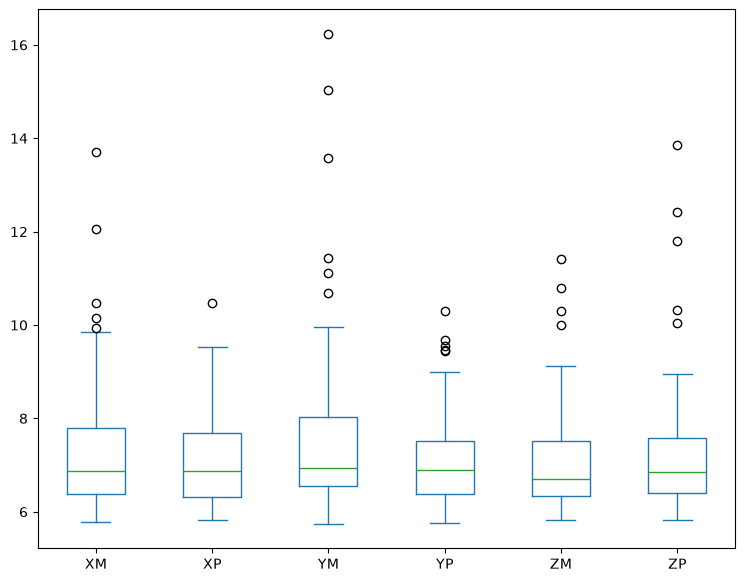

In [123]:
max_lat_dis_dose = lane_departures.groupby(['daqname', 'instance', 'DosingLevel'])['lat_dist'].apply(lambda x: x.abs().max())
# seems like DosingLevel doesn't change grouping of max_lat_dis
max_lat_dis_dose.unstack('DosingLevel').plot(kind = 'box', figsize = (9, 7))

## Question 3

### Part A

In [125]:
def eu_dis(x1, y1, z1, x2, y2, z2):
    """
    Helper func to calculate euclidean distance between two points of
        coordinates (x1, y1, z1) and (x2, y2, z2)
    """
    return math.sqrt((x2 - x1) ** 2 + (y2 - y1) ** 2 + (z2 - z1) ** 2)

obs = [
    (0 , 3, 0),
    (2, 0, 0),
    (0, 1, 3),
    (0, 1, 2),
    (-1, 0, 1),
    (1, 1, 1)
]

for i in range(len(obs)):
    ob = obs[i]
    x1, y1, z1 = ob
    print(f"The euclidean distance between observation {i + 1} at {ob} and the test data-point is {eu_dis(x1, y1, z1, 0, 0, 0)}")

The euclidean distance between observation 1 at (0, 3, 0) and the test data-point is 3.0
The euclidean distance between observation 2 at (2, 0, 0) and the test data-point is 2.0
The euclidean distance between observation 3 at (0, 1, 3) and the test data-point is 3.1622776601683795
The euclidean distance between observation 4 at (0, 1, 2) and the test data-point is 2.23606797749979
The euclidean distance between observation 5 at (-1, 0, 1) and the test data-point is 1.4142135623730951
The euclidean distance between observation 6 at (1, 1, 1) and the test data-point is 1.7320508075688772


### Part B

If `k = 1` then we find the one most nearest neighbor, which is observation $5$ as the distance between it and the test data-point is the smallest ($1.41$). Its predicted class is **Green**.

### Part C

When `k = 3` and uniform weighting (each of the three nearest neighbors contributes equally regardless of its distance.), the predicted probability would be $P(Y = Green) = \dfrac{1}{3} = 0.3333...$

### Part D

Yes because Green is the class of the closest neighbor so distance weighting gives it more influence than under uniform weighting. and its predicted probability will be higher than $0.333...$.

### Part E

In [126]:
x1s = [0, 2, 0, 0, -1, 1]
x2s = [3, 0, 1, 1, 0, 1]
x3s = [0, 0, 3, 2, 1, 1]
N = 6

mean_x1 = sum(x1s) / N
mean_x2 = sum(x2s) / N
mean_x3 = sum(x3s) / N

std_x1 = math.sqrt((sum((x - mean_x1)**2 for x in x1s) / N))
std_x2 = math.sqrt((sum((x - mean_x2)**2 for x in x2s) / N))
std_x3 = math.sqrt((sum((x - mean_x3)**2 for x in x3s) / N))

# Re-scale each data-point by subtracting that feature’s mean and dividing by its standard deviation
# and re-calc distance
# 1) test data-point
test1, test2, test3 = (
    (0 - mean_x1) / std_x1,
    (0 - mean_x2) / std_x2,
    (0 - mean_x3) / std_x3
)

# 2) observations
for i in range(N):
    ob = (
        (x1s[i] - mean_x1) / std_x1,
        (x2s[i] - mean_x2) / std_x2,
        (x3s[i] - mean_x3) / std_x3
    )
    x1, y1, z1 = ob
    print(f"The euclidean distance between scaled observation {i + 1} at {ob} and the scaled test data-point is {eu_dis(x1, y1, z1, test1, test2, test3)}")

The euclidean distance between scaled observation 1 at (-0.35355339059327373, 2.0, -1.0932163332202425) and the scaled test data-point is 3.0
The euclidean distance between scaled observation 2 at (1.7677669529663689, -1.0, -1.0932163332202425) and the scaled test data-point is 2.121320343559643
The euclidean distance between scaled observation 3 at (-0.35355339059327373, 0.0, 1.7179113807746667) and the scaled test data-point is 2.9836955314492535
The euclidean distance between scaled observation 4 at (-0.35355339059327373, 0.0, 0.7808688094430303) and the scaled test data-point is 2.1241928165661466
The euclidean distance between scaled observation 5 at (-1.414213562373095, -1.0, -0.15617376188860613) and the scaled test data-point is 1.4152910585769292
The euclidean distance between scaled observation 6 at (0.7071067811865476, 0.0, -0.15617376188860613) and the scaled test data-point is 1.7329306911956417


Using `k=3` and three neighbors, the three neighbors would be observations 5 (Green), 6 (Red), and 2 (Red). This is the same neighbors and `k` and uniform weighting as Part C so it will be the same result as Part C, which is about $0.3333...$

## Question 4

In [127]:
# imports
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import root_mean_squared_error

# read data
ozone = pd.read_csv("https://remiller1450.github.io/data/Ozone.csv")
ozone.head(5)

,Ozone,Solar,Wind,Temp,Day
0,41,190,7.4,67,121
1,36,118,8.0,72,122
2,12,149,12.6,74,123
3,18,313,11.5,62,124
4,23,299,8.6,65,127


### Part A

In [128]:
# Separate the outcome from the predictors
ozone_sep = ozone.drop(columns = ['Day'])

# Train test split
ozone_train, ozone_test = train_test_split(ozone_sep, test_size=0.2, random_state=3)

# Grab data
ozone_train_x = ozone_train.drop('Ozone', axis=1)
ozone_test_x = ozone_test.drop('Ozone', axis=1)
ozone_train_y = ozone_train['Ozone']
ozone_test_y = ozone_test['Ozone']

# Rescale training and testing data
standard_scaler = StandardScaler().fit(ozone_train_x)
train_X_scaled = standard_scaler.transform(ozone_train_x)
test_X_scaled = standard_scaler.transform(ozone_test_x)

### Part B

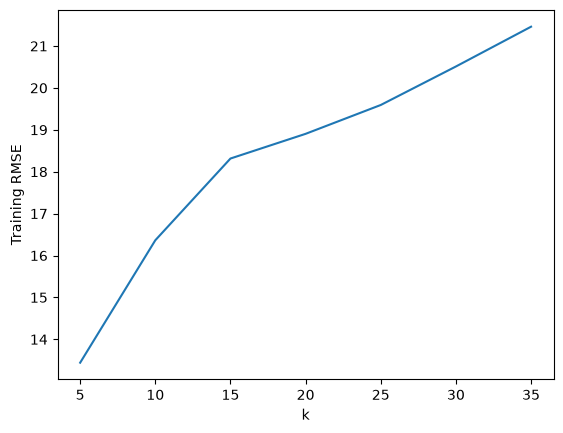

In [129]:
ks = range(5, 35 + 1, 5)
train_rmses = []

for k in ks:
    # do KNN regression to predict y
    knn_model = KNeighborsRegressor(n_neighbors=k, weights='uniform', p=2)  # Euclidean distance
    knn_model.fit(train_X_scaled, ozone_train_y)
    
    # report rmse on train data
    train_rmse = root_mean_squared_error(ozone_train_y, knn_model.predict(train_X_scaled))
    
    train_rmses.append(train_rmse)

plt.plot(ks, train_rmses)
plt.xlabel('k')
plt.ylabel('Training RMSE')
plt.show()

### Part C

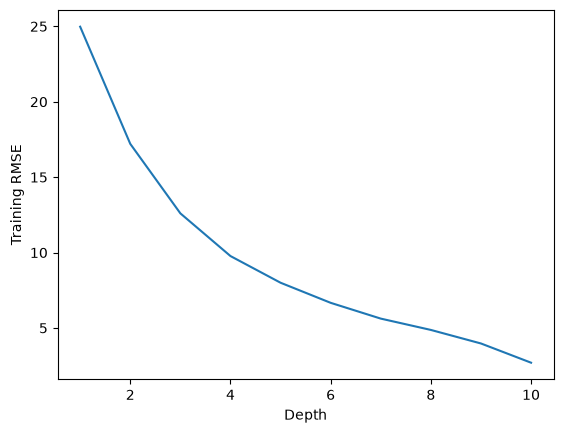

In [130]:
depths = range(1, 10 + 1)
train_rmses = []

for depth in depths:
    # do Decision Tree regression to predict y
    dt_model = DecisionTreeRegressor(max_depth=depth, random_state=7)
    dt_model.fit(ozone_train_x, ozone_train_y)
    
    # report rmse on train data
    train_rmse = root_mean_squared_error(ozone_train_y, dt_model.predict(ozone_train_x))
    
    train_rmses.append(train_rmse)

plt.plot(depths, train_rmses)
plt.xlabel('Depth')
plt.ylabel('Training RMSE')
plt.show()

### Part D

I think that it would be difficult to tell which model would perform better on the test set because the graphs from Part B and C only show training error. A model could perform well on training data and have low training RMSE but is overfitting and perform poorly on unseen test data.

### Part E

#### KNN

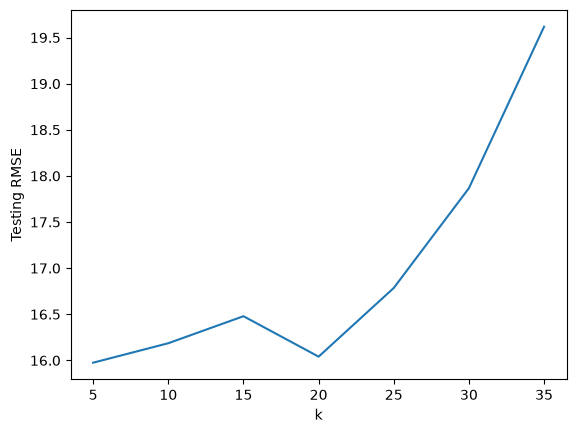

In [131]:
ks = range(5, 35 + 1, 5)
test_rmses = []

for k in ks:
    # do KNN regression to predict y
    knn_model = KNeighborsRegressor(n_neighbors=k, weights='uniform', p=2)  # Euclidean distance
    knn_model.fit(train_X_scaled, ozone_train_y)
    
    # report rmse on test data
    test_rmse = root_mean_squared_error(ozone_test_y, knn_model.predict(test_X_scaled))
    
    test_rmses.append(test_rmse)

plt.plot(ks, test_rmses)
plt.xlabel('k')
plt.ylabel('Testing RMSE')
plt.show()

#### Decision Tree

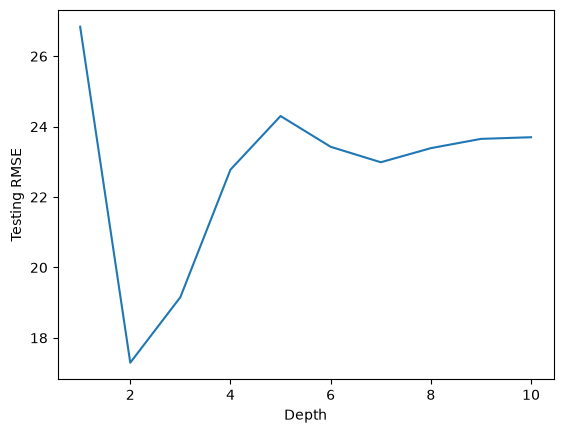

In [132]:
depths = range(1, 10 + 1)
test_rmses = []

for depth in depths:
    # do Decision Tree regression to predict y
    dt_model = DecisionTreeRegressor(max_depth=depth, random_state=7)
    dt_model.fit(ozone_train_x, ozone_train_y)
    
    # report rmse on train data
    test_rmse = root_mean_squared_error(ozone_test_y, dt_model.predict(ozone_test_x))
    
    test_rmses.append(test_rmse)

plt.plot(depths, test_rmses)
plt.xlabel('Depth')
plt.ylabel('Testing RMSE')
plt.show()

For the KNN model, the lowest test RMSE is about $16$ when `k=5`, which is lower than the best Decision Tree test RMSE of about $17$ at depth $2$. This supports my answer from Part D because Decision Tree with very low training error performed better on the training data have a higher testing error, thus performed worse than KNN model on unseen test data.

One important thing that stands out to me is that the difference in testing RMSE between the two model is very small, but a Decision Tree with a depth of $2$ is much easier to interpretable than a KNN model finding $5$ nearest neighbors.

### Part F

I would recommend the Decision Tree model with depth of $2$. Its error when tested on unseen data was only slightly higher than the best KNN model, but the best KNN model is at a complex level of computation and much harder to reason about when comparing to a Decision Tree. A Decision Tree uses a small number of clear decision rules based on factors such as solar, wind and temperature, so the city planner could trace the tree and understand why a particular ozone prediction was made. Thus, Decision Tree is a good choice if the city planner wants a balance of interpretability and performance.